## Strategy: Instead of temporal or spatial multiplexing, here we use 75 observables at the same time to exploit the high dimensionality.
## Task: Memory task y_k = s_(k-tau); tau=10 typically
## We finally calculate capacity C. This is a reproduction of the paper dynamical phase transitions in quantum reservoir computing.

In [1]:
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from Models import X, Y, Z, ZZ, Ising
from Density_matrix import trace_1, mixed_density_matrix
from sklearn.linear_model import LinearRegression
rng = np.random.default_rng(seed=42)

Module Hamiltonian Loaded!
Module Density Matrix has been loaded!


In [2]:
## Dataset (linear memory y_(n) = s_(n-delay))
delay=10
washout = 1000
train = 2000
test = 2000
# input
s = rng.uniform(0.0,1.0,5000)
s_washout = s[:washout]
s_train = s[washout:washout+train]
s_test = s[washout+train:washout+train+test]

#output
y = np.zeros(4000)
y_train = s[washout-delay:washout+train-delay]
y_test = s[washout+train-delay:washout+train+test-delay]

In [3]:
## System and initial state
N = 5
J=1
h=0.5
Hamiltonian, Jij = Ising(N, J, h)
rho = mixed_density_matrix(10,2,N)  # Initial mixed state

E, U = eigh(Hamiltonian)
energy_diffs = E[:, np.newaxis] - E[np.newaxis, :]
phase_factors = np.exp(-1j * energy_diffs * 1)

def time_evolve(rho_0): #time evolve t=1 
    rho_energy = U.conj().T @ rho_0 @ U
    rho_energy_t = rho_energy * phase_factors
    rho_t = U @ rho_energy_t @ U.conj().T
    return rho_t

def inpt(rho, s, N):
    a = np.array([[0],[1]])
    b = np.array([[1],[0]])
    psi_s = np.sqrt(1-s)*a + np.sqrt(s)*b
    rho_s = np.outer(psi_s, psi_s)
    rho_rest = trace_1(rho,N)
    density_matrix = np.kron(rho_s, rho_rest)
    return density_matrix

x = X(N)
y = Y(N)
z = Z(N)
zz = ZZ(N)  #list of all pairs
obs  = list(x) + list(y) + list(z) + zz

In [4]:
## Washout and training
# Washout
for s in s_washout:
    rho = inpt(rho,s,N)
    rho = time_evolve(rho)

X = np.zeros([train,len(obs)])
for k in range(len(s_train)):
    rho = inpt(rho,s_train[k],N)
    rho = time_evolve(rho)
    for j in range(len(obs)):
        X[k,j] = np.real(np.trace(rho@obs[j]))

model = LinearRegression()
model.fit(X,y_train)

    

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
## Testing
y_pred = []
for s in s_test:
    rho = inpt(rho,s,N)
    rho = time_evolve(rho)
    x = []
    for i in range(len(obs)):
        x.append(np.real(np.trace(rho@obs[i])),)
    x = np.array(x)
    x = x[np.newaxis,:]
    y_pred.append(model.predict(x))

y_pred = np.array(y_pred)
y_pred = y_pred[:,0]

(3000.0, 3100.0)

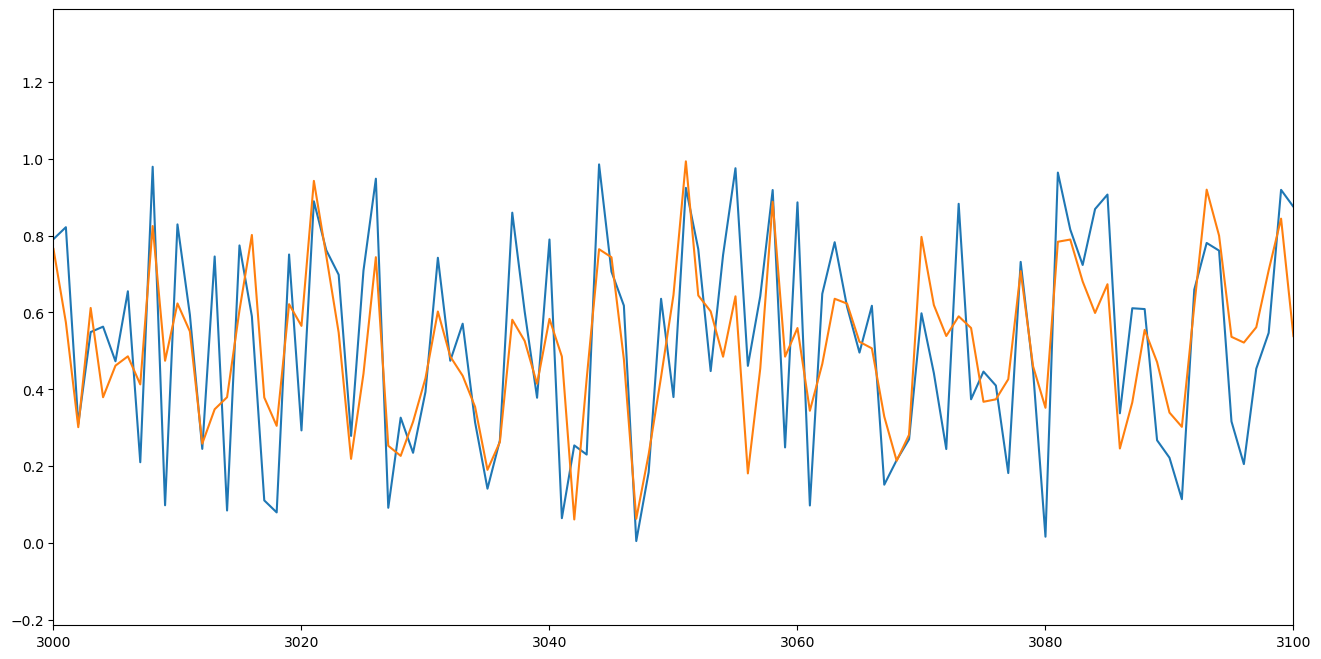

In [6]:
T_test = np.linspace(3000,4999,2000)
plt.figure(figsize=[16,8])
plt.plot(T_test,y_test)
plt.plot(T_test,y_pred)
plt.xlim(3000,3100)

In [10]:
cov = np.cov(y_test,y_pred)
C = (cov[0,1]**2)/(cov[0,0]*cov[1,1])
print(f'C={C:.2f}')

C=0.48
